# F1-SIS: Safety Car (SC) Risk Estimation Model

## 1. Objective
Build a calibrated probabilistic model that estimates:

    P(new Safety Car occurs within the next 1, 3, 5, and 10 laps)

The output must be continuous probabilities, not Boolean predictions.
The purpose is to estimate how much probability the Monte Carlo strategy simulator should assign to future SC scenarios, providing uncertainty weighting rather than deterministic crash prediction.

## 2. Problem Definition
We use a **two-stage risk approach**:

    Historical SC Risk  (Prior)
            +
    Current Race Evidence (Live)
            ↓
    Updated SC Risk

The live race-state component updates the historical prior only when there is actual evidence (e.g., yellow flags, close battles, field compression) that the current race is diverging from its historical baseline.


---

## 3. Literature Basis

This probabilistic formulation is built upon the **Heilmeier Safety Car Probability approach** which establishes $P(SC | \text{circuit}, \text{race progress})$.

Our live risk-updating approach is a direct **extension** of this historical method. Instead of stopping at the historical prior, we dynamically update it using live race evidence in a Bayesian-style logit update framework.


In [34]:
import os, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    brier_score_loss, average_precision_score, log_loss, roc_auc_score
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
import joblib

DATA_DIR      = os.path.join('data_fastf1_v1', 'laps')
HORIZONS      = [1, 3, 5, 10]
RANDOM_SEED   = 42
TRAIN_SEASONS = [2018, 2019, 2020, 2021, 2022]
VAL_SEASONS   = [2023]
TEST_SEASONS  = [2024, 2025]

PROGRESS_BINS   = [0, 0.01, 0.20, 0.40, 0.60, 0.80, 1.01]
PROGRESS_LABELS = ['Lap1', '2-20', '20-40', '40-60', '60-80', '80-100']
SHRINKAGE_K     = 20

print('Config ready.')

Config ready.


---

## 4. Data Loading & Temporary Race State Adapter

A separate **Race State Manager** is being developed for live integration.
For this notebook, we build a temporary adapter that generates causal race-state variables directly from historical CSV data.

**Live Race Evidence Features Generated:**
- `close_battles`: Count of cars within 1.0s of the car ahead.
- `field_spread`: Std Dev of gaps to leader (indicates field compression).
- `sector_anomaly`: High variance in sector times indicating incidents.
- `recent_retirements`: Count of cars dropping out in the last 3 laps.


In [35]:
TS_SC = '4'; TS_VSC = '6'; TS_VSC_ENDING = '7'; TS_YELLOW = '2'

def decode_track_status(s):
    s = s.astype(str).str.strip()
    return pd.DataFrame({
        'sc_active': s.str.contains(TS_SC, na=False),
        'vsc_active': s.str.contains(TS_VSC, na=False),
        'vsc_ending': s.str.contains(TS_VSC_ENDING, na=False),
        'yellow': s.str.contains(TS_YELLOW, na=False),
    })

def build_planned_laps_lookup(data_dir=DATA_DIR):
    """Build a causal lookup: planned race laps per circuit from earlier seasons only."""
    lookup = {}
    for season_dir in sorted(Path(data_dir).iterdir()):
        if not season_dir.is_dir(): continue
        try: year = int(season_dir.name)
        except ValueError: continue
        for f in sorted(season_dir.glob('*.csv')):
            try:
                df = pd.read_csv(f, low_memory=False, usecols=['LapNumber'])
                max_lap = pd.to_numeric(df['LapNumber'], errors='coerce').max()
                if pd.notna(max_lap):
                    circuit = f.stem
                    if circuit not in lookup:
                        lookup[circuit] = []
                    lookup[circuit].append((year, int(max_lap)))
            except Exception:
                pass
    return lookup

def get_planned_laps(circuit, year, lookup, global_default=58):
    """Get planned race laps using only data from EARLIER seasons (causal proxy)."""
    if circuit in lookup:
        prior = [laps for y, laps in lookup[circuit] if y < year]
        if prior:
            return int(np.median(prior))
    # Global fallback from all prior data
    all_prior = [laps for c in lookup for y, laps in lookup[c] if y < year]
    if all_prior:
        return int(np.median(all_prior))
    return global_default

def load_and_adapt(data_dir=DATA_DIR):
    # Build causal planned-laps lookup first
    planned_lookup = build_planned_laps_lookup(data_dir)

    frames = []
    for season_dir in sorted(Path(data_dir).iterdir()):
        if not season_dir.is_dir(): continue
        try: year = int(season_dir.name)
        except ValueError: continue
        for f in sorted(season_dir.glob('*.csv')):
            try:
                df = pd.read_csv(f, low_memory=False)
                df['Year'] = year
                df['race_id'] = f'{year}_{f.stem}'
                df['circuit'] = f.stem
                frames.append(df)
            except Exception as e:
                print(f'WARNING {f.name}: {e}')
    df_raw = pd.concat(frames, ignore_index=True)
    print(f'Raw drivers x laps rows: {len(df_raw):,}')

    if 'Location' not in df_raw.columns:
        df_raw['Location'] = df_raw.get('RaceName', 'Unknown')

    decoded = decode_track_status(df_raw['TrackStatus'])
    for col in decoded.columns: df_raw[col] = decoded[col]

    df_raw['LapNumber'] = pd.to_numeric(df_raw['LapNumber'], errors='coerce')
    for c in ['LapTimeSeconds','Sector1TimeSeconds','Sector2TimeSeconds','Sector3TimeSeconds',
              'GapToLeaderSeconds','IntervalToPositionAheadSeconds','TyreLife']:
        if c in df_raw.columns: df_raw[c] = pd.to_numeric(df_raw[c], errors='coerce')
    df_raw = df_raw.dropna(subset=['LapNumber','race_id'])
    df_raw['LapNumber'] = df_raw['LapNumber'].astype(int)

    # --- Race State Adapter (Driver Level -> Race Level) ---
    df_raw['is_close_battle'] = (df_raw['IntervalToPositionAheadSeconds'] < 1.0).astype(int)
    df_raw['pitted'] = df_raw['PitInTime'].notna() if 'PitInTime' in df_raw.columns else False

    # Fix: Do NOT count 'Deleted' laps as retirements
    if 'Deleted' in df_raw.columns:
        df_raw.loc[df_raw['Deleted'] == True, 'is_close_battle'] = 0

    grp = df_raw.groupby(['race_id','Year','Location','LapNumber','circuit'])
    agg = grp.agg(
        sc_active=('sc_active', 'any'),
        vsc_active=('vsc_active', 'any'),
        vsc_ending=('vsc_ending', 'any'),
        yellow=('yellow', 'any'),
        n_cars=('Driver', 'nunique'),
        close_battles=('is_close_battle', 'sum'),
        field_spread=('GapToLeaderSeconds', 'std'),
        s1_med=('Sector1TimeSeconds', 'median'),
        s2_med=('Sector2TimeSeconds', 'median'),
        s3_med=('Sector3TimeSeconds', 'median'),
        tyre_age_med=('TyreLife', 'median'),
        tyre_age_std=('TyreLife', 'std'),       # NEW: tyre age spread
        total_pits=('pitted', 'sum'),
    ).reset_index()

    # Planned race laps (causal — from prior seasons only)
    agg['planned_laps'] = agg.apply(
        lambda row: get_planned_laps(row['circuit'], row['Year'], planned_lookup), axis=1
    )
    # Also keep actual total laps for target construction
    max_laps = df_raw.groupby('race_id')['LapNumber'].max().rename('total_laps').reset_index()
    agg = agg.merge(max_laps, on='race_id', how='left')

    # Race progress uses PLANNED laps (causal, no future leakage)
    agg['race_progress']  = (agg['LapNumber'] / agg['planned_laps']).clip(upper=1.0)
    agg['laps_remaining'] = (agg['planned_laps'] - agg['LapNumber']).clip(lower=0)
    agg = agg.sort_values(['race_id','LapNumber'])

    # Retirements tracking (using car count drops only, not deleted laps)
    agg['peak_cars'] = agg.groupby('race_id')['n_cars'].transform('cummax')
    agg['retirements_total'] = (agg['peak_cars'] - agg['n_cars']).clip(lower=0)
    agg['recent_retirements'] = agg.groupby('race_id')['retirements_total'].diff(3).fillna(0).clip(lower=0)

    # Sector anomalies (sudden median time spikes)
    agg['s1_anom'] = agg.groupby('race_id')['s1_med'].transform(lambda x: x / x.shift(1).rolling(5, min_periods=1).median() - 1).fillna(0)
    agg['s2_anom'] = agg.groupby('race_id')['s2_med'].transform(lambda x: x / x.shift(1).rolling(5, min_periods=1).median() - 1).fillna(0)
    agg['s3_anom'] = agg.groupby('race_id')['s3_med'].transform(lambda x: x / x.shift(1).rolling(5, min_periods=1).median() - 1).fillna(0)
    agg['sector_anomaly_score'] = agg[['s1_anom','s2_anom','s3_anom']].max(axis=1).clip(lower=0)

    # Yellow flag rolling
    agg['yellow_last3'] = agg.groupby('race_id')['yellow'].transform(lambda x: x.astype(int).shift(1).rolling(3, min_periods=1).sum()).fillna(0)

    # NEW: Pit activity in last 3 laps
    agg['pit_activity_last3'] = agg.groupby('race_id')['total_pits'].transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).sum()
    ).fillna(0)

    # NEW: Tyre age spread across the field
    agg['tyre_age_spread'] = agg['tyre_age_std'].fillna(0)

    print(f'Race-level adapter output rows: {len(agg):,}')
    return agg

df_laps = load_and_adapt()

Raw drivers x laps rows: 188,482
Race-level adapter output rows: 10,317


---

## 5. SC Event Detection & Targets

We strictly target the **start** of a Safety Car (`SC_START`), not every active SC lap.
Horizons extending past `total_laps` are appropriately right-censored (`np.nan`).


In [36]:
def detect_events_and_targets(df, horizons=HORIZONS):
    df = df.sort_values(['race_id','LapNumber']).copy()
    # SC Start Detection
    sc_prev = df.groupby('race_id')['sc_active'].shift(1, fill_value=False)
    df['sc_started'] = ((~sc_prev) & df['sc_active']).astype(int)

    # VSC Start Detection
    df['vsc_truly_active'] = df['vsc_active'] & ~df['vsc_ending']
    vsc_prev = df.groupby('race_id')['vsc_truly_active'].shift(1, fill_value=False)
    df['vsc_started'] = ((~vsc_prev) & df['vsc_truly_active']).astype(int)

    # NEW: Laps since last SC (causal — uses only past SC events)
    def compute_laps_since_sc(grp):
        laps_since = pd.Series(np.nan, index=grp.index)
        last_sc_lap = np.nan
        for idx, row in grp.iterrows():
            if not np.isnan(last_sc_lap):
                laps_since[idx] = row['LapNumber'] - last_sc_lap
            if row['sc_started'] == 1:
                last_sc_lap = row['LapNumber']
        return laps_since.fillna(999)  # 999 = no prior SC in this race
    df['laps_since_last_sc'] = df.groupby('race_id', group_keys=False).apply(compute_laps_since_sc)

    # Target construction uses ACTUAL total_laps (ground truth for labeling)
    rows = []
    for race_id, grp in df.groupby('race_id'):
        grp = grp.sort_values('LapNumber').reset_index(drop=True)
        sc_starts = grp.loc[grp['sc_started']==1, 'LapNumber'].values
        total = grp['total_laps'].iloc[0]
        for _, row in grp.iterrows():
            if row['sc_active']: continue
            t = row['LapNumber']
            future = sc_starts[sc_starts > t]
            next_sc = future[0] if len(future) else np.nan
            laps_until = next_sc - t if not np.isnan(next_sc) else np.nan
            rec = {'race_id': race_id, 'LapNumber': t}
            for n in horizons:
                if t + n > total:
                    rec[f'SC_next_{n}'] = np.nan
                elif not np.isnan(laps_until) and laps_until <= n:
                    rec[f'SC_next_{n}'] = 1
                else:
                    rec[f'SC_next_{n}'] = 0
            rows.append(rec)
    targets = pd.DataFrame(rows)
    print(f'Target instances: {len(targets):,}')
    non_sc = (~df['sc_active']).sum()
    sc_ev  = df['sc_started'].sum()
    print(f'Actual SC_START rate: {sc_ev} events / {non_sc} non-SC laps = {sc_ev/non_sc:.4f}')
    return df, targets

df_laps, targets = detect_events_and_targets(df_laps)

Target instances: 9,645
Actual SC_START rate: 128 events / 9645 non-SC laps = 0.0133


---

## 6. Historical SC Prior ($P_{historical}$)

Computed strictly from the training set to prevent leakage.
We calculate the smoothed SC rate per circuit and per race-progress bin (Heilmeier style).


In [37]:
def build_historical_prior(df_laps, train_race_ids, k=SHRINKAGE_K):
    train = df_laps[df_laps['race_id'].isin(train_race_ids)].copy()
    non_sc = train[~train['sc_active']].copy()

    global_rate = non_sc['sc_started'].sum() / len(non_sc)
    non_sc['progress_bin'] = pd.cut(non_sc['race_progress'], bins=PROGRESS_BINS, labels=PROGRESS_LABELS, right=False)

    global_prog = non_sc.groupby('progress_bin', observed=True).agg(
        ev=('sc_started','sum'), n=('sc_started','count')).assign(
        rate=lambda x: x['ev']/x['n']).reset_index()

    circ_prog = non_sc.groupby(['Location','progress_bin'], observed=True).agg(
        ev=('sc_started','sum'), n=('sc_started','count')).reset_index()
    circ_prog = circ_prog.merge(global_prog[['progress_bin','rate']], on='progress_bin', how='left')
    circ_prog['p_historical'] = (circ_prog['ev'] + k * circ_prog['rate']) / (circ_prog['n'] + k)

    return circ_prog, global_rate

train_ids = df_laps.loc[df_laps['Year'].isin(TRAIN_SEASONS), 'race_id'].unique()
circ_prog, global_rate = build_historical_prior(df_laps, train_ids)


---

## 7. Causal Race-State Features

Merging the historical prior with live causal features.


In [38]:
df_feat = df_laps.sort_values(['race_id','LapNumber']).copy()
df_feat['sc_count_cumul'] = df_feat.groupby('race_id')['sc_started'].cumsum().shift(1).fillna(0)
df_feat['progress_bin'] = pd.cut(df_feat['race_progress'], bins=PROGRESS_BINS, labels=PROGRESS_LABELS, right=False)

# Attach prior
df_feat = df_feat.merge(circ_prog[['Location','progress_bin','p_historical']], on=['Location','progress_bin'], how='left')
df_feat['p_historical'] = df_feat['p_historical'].fillna(global_rate)

# Logit transform of the prior (clip to avoid inf)
eps = 1e-6
df_feat['logit_p_hist'] = np.log(df_feat['p_historical'].clip(eps, 1-eps) / (1 - df_feat['p_historical'].clip(eps, 1-eps)))

# Updated feature list with new causal features
live_features = [
    'close_battles', 'field_spread', 'sector_anomaly_score',
    'recent_retirements', 'yellow_last3', 'sc_count_cumul',
    'pit_activity_last3', 'laps_since_last_sc', 'tyre_age_spread'  # NEW
]
df_feat[live_features] = df_feat[live_features].fillna(0)

feature_df = targets.merge(
    df_feat[['race_id','LapNumber','Year','Location','p_historical','logit_p_hist',
             'sc_active', 'sc_started', 'race_progress'] + live_features],
    on=['race_id','LapNumber']
)
print(f'Feature DataFrame shape: {feature_df.shape}')
print(f'Live features: {live_features}')

Feature DataFrame shape: (9645, 22)
Live features: ['close_battles', 'field_spread', 'sector_anomaly_score', 'recent_retirements', 'yellow_last3', 'sc_count_cumul', 'pit_activity_last3', 'laps_since_last_sc', 'tyre_age_spread']


---

## 8. Risk Update Models

### 8a. Per-Lap Logit Update (Original)

Formulation: $logit(P_t) = \beta_0 logit(P_{hist}) + \sum \beta_i X_{live} + intercept$

Uses LogisticRegression to model the *per-lap hazard*.
After predicting $h_t$, expand to horizons via $P_n = 1 - (1 - h_t)^n$ (constant hazard assumption).

In [39]:
train_df = feature_df[feature_df['Year'].isin(TRAIN_SEASONS)].copy()
val_df   = feature_df[feature_df['Year'].isin(VAL_SEASONS)].copy()
test_df  = feature_df[feature_df['Year'].isin(TEST_SEASONS)].copy()

X_cols = ['logit_p_hist'] + live_features

# === Logit Update Model ===
def train_logit_update(train_data, val_data, X_cols):
    sub_train = train_data.dropna(subset=['SC_next_1', *X_cols]).copy()
    sub_val   = val_data.dropna(subset=['SC_next_1', *X_cols]).copy()
    X_tr, y_tr = sub_train[X_cols], sub_train['SC_next_1'].astype(int)
    X_va, y_va = sub_val[X_cols], sub_val['SC_next_1'].astype(int)

    model = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
    model.fit(X_tr, y_tr)

    print("Logit Model Coefficients:")
    for f, coef in zip(X_cols, model.coef_[0]):
        print(f"  {f:<25}: {coef:.4f}")
    print(f"  Intercept                : {model.intercept_[0]:.4f}")

    return model

logit_model = train_logit_update(train_df, val_df, X_cols)

Logit Model Coefficients:
  logit_p_hist             : 0.4061
  close_battles            : 0.0429
  field_spread             : 0.0251
  sector_anomaly_score     : 0.8319
  recent_retirements       : -0.0678
  yellow_last3             : 0.0402
  sc_count_cumul           : 0.3888
  pit_activity_last3       : 0.0426
  laps_since_last_sc       : 0.0007
  tyre_age_spread          : -0.0414
  Intercept                : -0.0574


---

## 9. XGBoost Benchmark & Calibration

In [40]:
from sklearn.calibration import FrozenEstimator
def train_xgb_benchmark(train_data, val_data, X_cols, horizon):
    sub_train = train_data.dropna(subset=[f'SC_next_{horizon}', *X_cols])
    sub_val   = val_data.dropna(subset=[f'SC_next_{horizon}', *X_cols])
    X_tr, y_tr = sub_train[X_cols], sub_train[f'SC_next_{horizon}'].astype(int)
    X_va, y_va = sub_val[X_cols], sub_val[f'SC_next_{horizon}'].astype(int)

    model = xgb.XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.05,
                              random_state=RANDOM_SEED, verbosity=0)
    model.fit(X_tr, y_tr)

    # Platt scaling calibration on validation set
    calibrated = CalibratedClassifierCV(FrozenEstimator(model), method='sigmoid')
    calibrated.fit(X_va, y_va)

    return model, calibrated

xgb_models = {}
xgb_calibrated = {}
for n in HORIZONS:
    raw_model, cal_model = train_xgb_benchmark(train_df, val_df, X_cols, n)
    xgb_models[n] = raw_model
    xgb_calibrated[n] = cal_model
    print(f"  Horizon {n:>2}: XGBoost trained & calibrated")

print("All XGBoost models trained and calibrated with Platt scaling.")

  Horizon  1: XGBoost trained & calibrated
  Horizon  3: XGBoost trained & calibrated
  Horizon  5: XGBoost trained & calibrated
  Horizon 10: XGBoost trained & calibrated
All XGBoost models trained and calibrated with Platt scaling.


---

## 10. Sequential Replay

Replay the race chronologically using three approaches:
1. **Historical baseline**: raw historical prior expanded to horizons
2. **Logit Update (constant hazard)**: per-lap hazard expanded via $P_n = 1 - (1-h_t)^n$
3. **XGBoost (calibrated)**: per-horizon calibrated XGBoost predictions

In [41]:
def hazard_to_probs(h_t, horizons=HORIZONS):
    """Constant hazard expansion."""
    return {n: 1 - (1 - h_t)**n for n in horizons}

def replay_race(race_id, data_df, logit_model, xgb_dict, xgb_cal_dict, X_cols):
    rows = []
    race_data = data_df[data_df['race_id']==race_id].sort_values('LapNumber')
    for _, row in race_data.iterrows():
        X_curr = pd.DataFrame([row[X_cols].values], columns=X_cols)

        # 1. Logit update — constant hazard
        h_t = logit_model.predict_proba(X_curr)[0, 1]
        probs_logit = hazard_to_probs(h_t)

        # 2. Historical Only baseline
        h_hist = row['p_historical']
        probs_hist = hazard_to_probs(h_hist)

        rec = {
            'race_id': race_id, 'LapNumber': row['LapNumber'],
            'p_historical': row['p_historical'], 'h_updated': h_t,
            'sc_started': row.get('sc_started', 0),
            'sc_active': row.get('sc_active', False)
        }
        for n in HORIZONS:
            rec[f'SC_next_{n}'] = row.get(f'SC_next_{n}', np.nan)
            rec[f'P_SC_{n}_hist'] = probs_hist[n]
            rec[f'P_SC_{n}_update'] = probs_logit[n]
            if n in xgb_cal_dict:
                rec[f'P_SC_{n}_xgb_cal'] = xgb_cal_dict[n].predict_proba(X_curr)[0, 1]
            if n in xgb_dict:
                rec[f'P_SC_{n}_xgb'] = xgb_dict[n].predict_proba(X_curr)[0, 1]
        rows.append(rec)
    return pd.DataFrame(rows)

# Demo replay
abu_ids = [r for r in feature_df['race_id'].unique() if 'Abu' in r and '2021' in r]
if abu_ids:
    replay_df = replay_race(abu_ids[0], feature_df, logit_model, xgb_models, xgb_calibrated, X_cols)
    print(f"Replayed {abu_ids[0]}")

Replayed 2021_Abu_Dhabi_Grand_Prix


---

## 11 & 12. Comprehensive Evaluation

Compare all models: Historical Baseline, Logit Update, XGBoost (raw), and XGBoost (calibrated).

Metrics: Brier Score, Log Loss, PR-AUC, ROC-AUC.
Evaluation on both validation (2023) and test (2024, 2025) sets with bootstrap confidence intervals.

In [42]:
def evaluate_all(data_df, logit_model, xgb_dict, xgb_cal_dict, X_cols, label=""):
    all_replays = []
    for r_id in data_df['race_id'].unique():
        all_replays.append(replay_race(r_id, data_df, logit_model, xgb_dict, xgb_cal_dict, X_cols))
    res_df = pd.concat(all_replays)

    metrics = []
    model_cols = [
        ('Historical', 'P_SC_{n}_hist'),
        ('Logit_Update', 'P_SC_{n}_update'),
        ('XGBoost', 'P_SC_{n}_xgb'),
        ('XGBoost_Cal', 'P_SC_{n}_xgb_cal'),
    ]
    for n in HORIZONS:
        sub = res_df.dropna(subset=[f'SC_next_{n}'])
        y_true = sub[f'SC_next_{n}'].astype(int)
        if len(y_true) < 10 or y_true.sum() == 0: continue
        for model_name, col_template in model_cols:
            col = col_template.format(n=n)
            if col not in sub.columns: continue
            y_prob = sub[col].clip(1e-6, 1-1e-6)
            try:
                roc = roc_auc_score(y_true, y_prob)
            except ValueError:
                roc = np.nan
            metrics.append({
                'Horizon': n, 'Model': model_name,
                'Brier': brier_score_loss(y_true, y_prob),
                'LogLoss': log_loss(y_true, y_prob),
                'PR-AUC': average_precision_score(y_true, y_prob),
                'ROC-AUC': roc,
            })
    return pd.DataFrame(metrics), res_df

def bootstrap_metrics(res_df, n_bootstrap=200, seed=42):
    rng = np.random.RandomState(seed)
    race_ids = res_df['race_id'].unique()
    all_boots = []
    for _ in range(n_bootstrap):
        sampled_races = rng.choice(race_ids, size=len(race_ids), replace=True)
        boot_df = pd.concat([res_df[res_df['race_id'] == r] for r in sampled_races])
        model_cols = [
            ('Historical', 'P_SC_{n}_hist'),
            ('Logit_Update', 'P_SC_{n}_update'),
            ('XGBoost_Cal', 'P_SC_{n}_xgb_cal'),
        ]
        for n in HORIZONS:
            sub = boot_df.dropna(subset=[f'SC_next_{n}'])
            y_true = sub[f'SC_next_{n}'].astype(int)
            if len(y_true) < 10 or y_true.sum() == 0: continue
            for model_name, col_template in model_cols:
                col = col_template.format(n=n)
                if col not in sub.columns: continue
                y_prob = sub[col].clip(1e-6, 1-1e-6)
                try:
                    all_boots.append({
                        'Horizon': n, 'Model': model_name,
                        'Brier': brier_score_loss(y_true, y_prob),
                    })
                except Exception:
                    pass
    boot_df = pd.DataFrame(all_boots)
    ci = boot_df.groupby(['Horizon','Model'])['Brier'].quantile([0.025, 0.975]).unstack()
    ci.columns = ['Brier_2.5%', 'Brier_97.5%']
    return ci.reset_index()

# === Validation Set Evaluation ===
print("=" * 60)
print("VALIDATION SET (2023)")
print("=" * 60)
val_metrics, val_replays = evaluate_all(val_df, logit_model, xgb_models, xgb_calibrated, X_cols, "Validation")
if not val_metrics.empty:
    print("\nBrier Scores:")
    print(val_metrics.pivot(index='Horizon', columns='Model', values='Brier').to_string())
    print("\nPR-AUC:")
    print(val_metrics.pivot(index='Horizon', columns='Model', values='PR-AUC').to_string())
    print("\nROC-AUC:")
    print(val_metrics.pivot(index='Horizon', columns='Model', values='ROC-AUC').to_string())

# === Test Set Evaluation ===
print("\n" + "=" * 60)
print("TEST SET (2024, 2025)")
print("=" * 60)
test_metrics, test_replays = evaluate_all(test_df, logit_model, xgb_models, xgb_calibrated, X_cols, "Test")
if not test_metrics.empty:
    print("\nBrier Scores:")
    print(test_metrics.pivot(index='Horizon', columns='Model', values='Brier').to_string())
    print("\nPR-AUC:")
    print(test_metrics.pivot(index='Horizon', columns='Model', values='PR-AUC').to_string())
    print("\nROC-AUC:")
    print(test_metrics.pivot(index='Horizon', columns='Model', values='ROC-AUC').to_string())

# === Bootstrap CIs ===
print("\n" + "=" * 60)
print("Bootstrap 95% CIs (Brier Score, Test Set)")
print("=" * 60)
if len(test_replays) > 0:
    ci_df = bootstrap_metrics(test_replays)
    print(ci_df.to_string(index=False))

VALIDATION SET (2023)

Brier Scores:
Model    Historical  Logit_Update   XGBoost  XGBoost_Cal
Horizon                                                 
1          0.010518      0.010423  0.010409     0.010422
3          0.031879      0.030600  0.030340     0.029783
5          0.052174      0.049046  0.049085     0.048775
10         0.103448      0.090499  0.094228     0.092378

PR-AUC:
Model    Historical  Logit_Update   XGBoost  XGBoost_Cal
Horizon                                                 
1          0.010518      0.035862  0.057240     0.057240
3          0.031879      0.071188  0.088876     0.088876
5          0.052174      0.091233  0.087622     0.087622
10         0.103448      0.179027  0.139419     0.139419

ROC-AUC:
Model    Historical  Logit_Update   XGBoost  XGBoost_Cal
Horizon                                                 
1               0.5      0.678093  0.575005     0.575005
3               0.5      0.677666  0.496488     0.496488
5               0.5      0.65602

---

## 13. Enhanced Visualizations

- Multi-horizon risk-wave plot with SC event markers
- Calibration reliability diagram
- Feature importance analysis

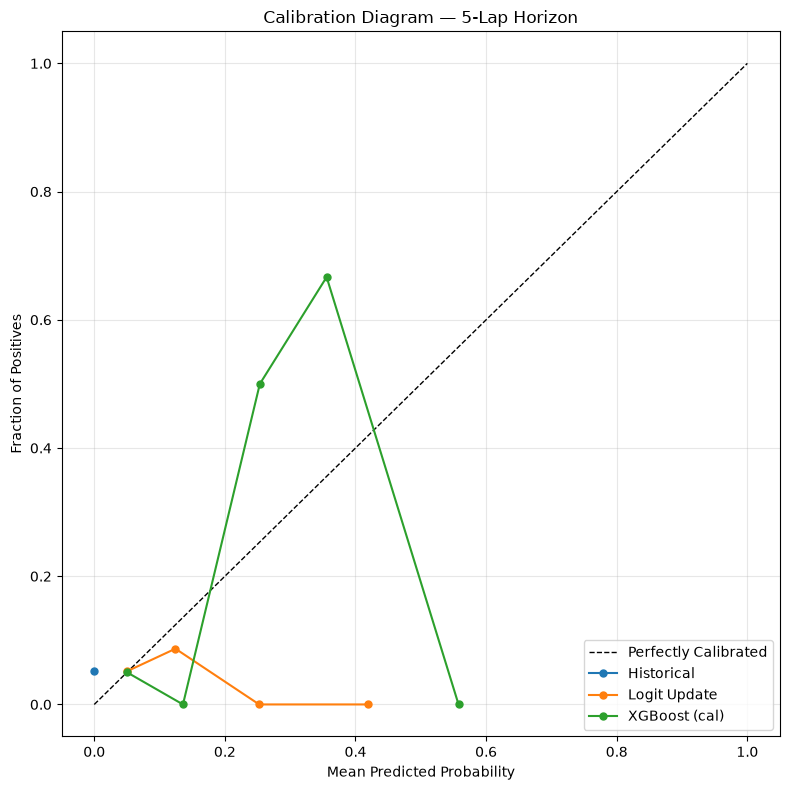

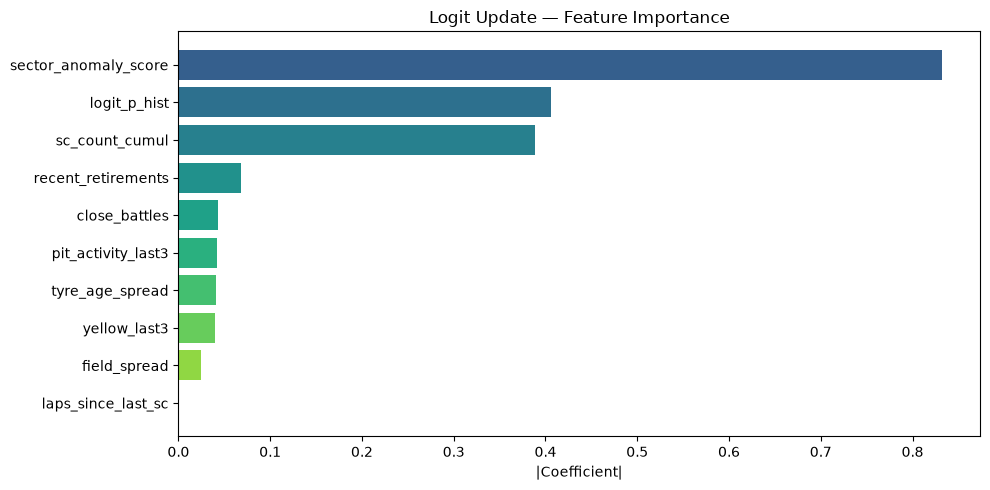

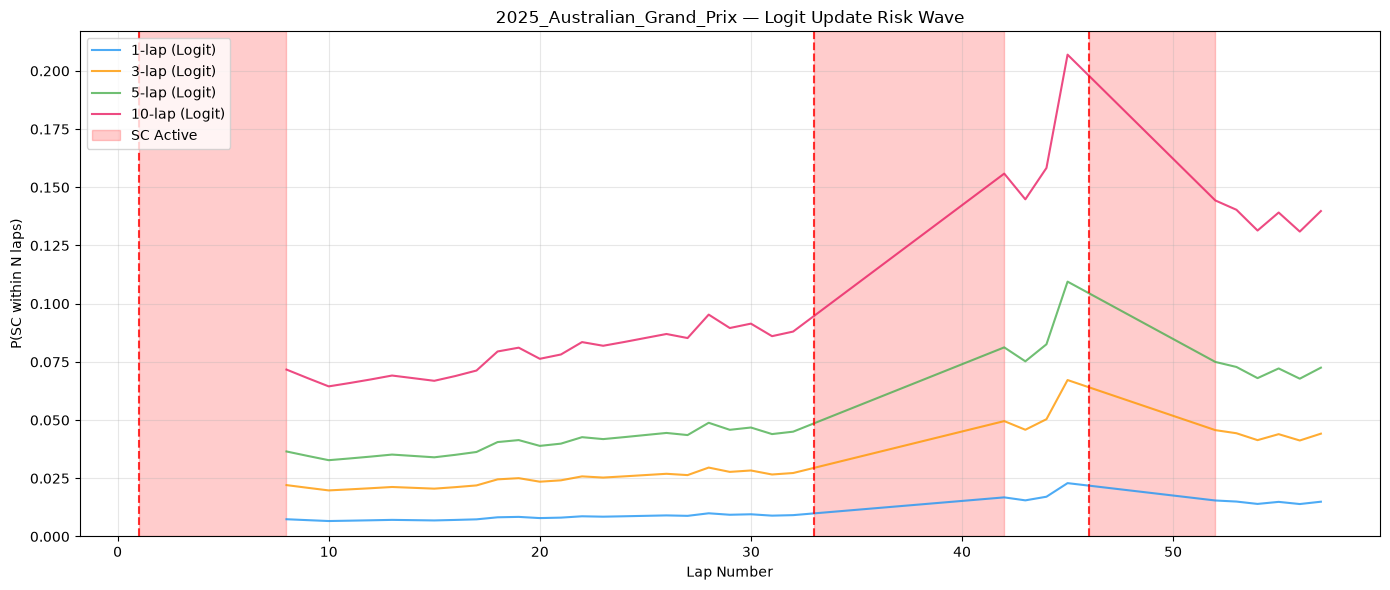

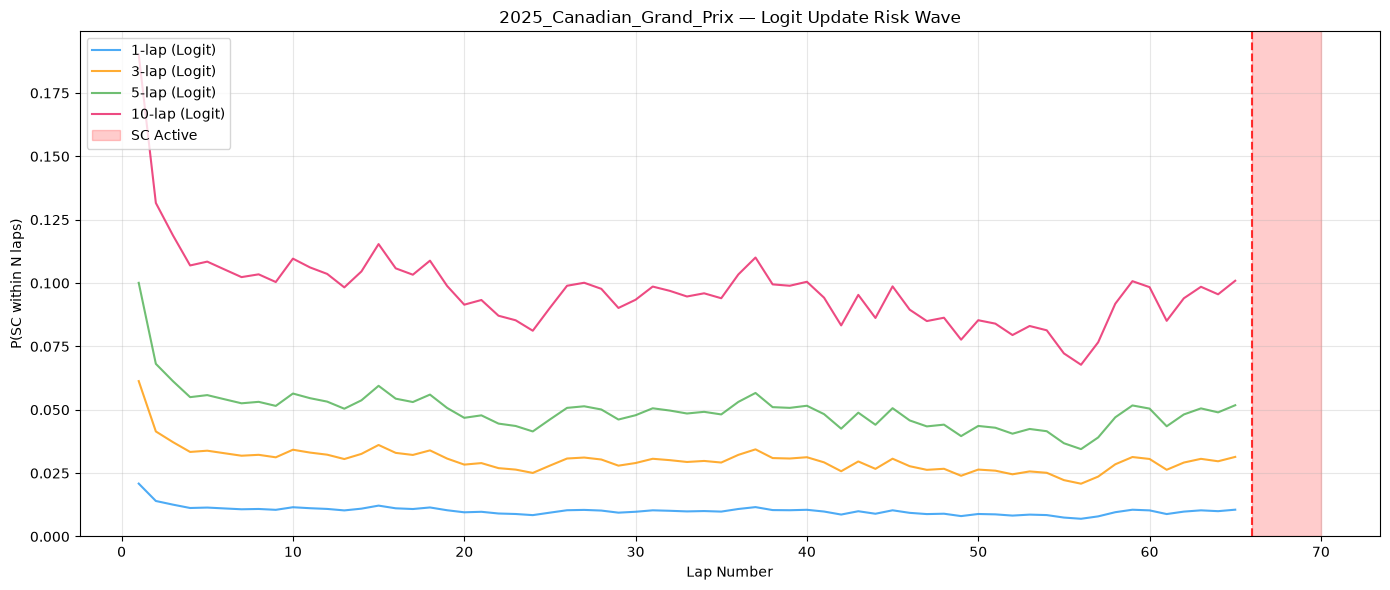

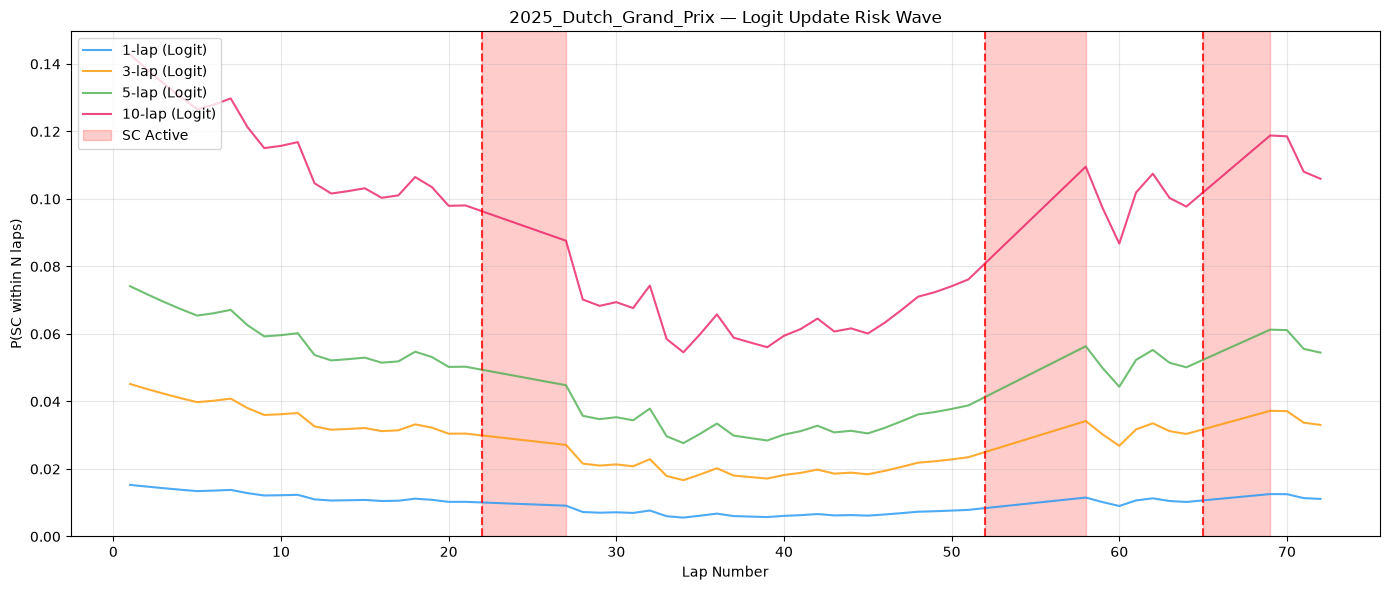

In [43]:
def plot_risk_wave(r_id, horizons_to_show=None):
    if horizons_to_show is None:
        horizons_to_show = HORIZONS
    if r_id not in feature_df['race_id'].unique():
        print(f"Cannot plot {r_id}, not in dataset.")
        return
    df_plot = replay_race(r_id, feature_df, logit_model, xgb_models, xgb_calibrated, X_cols)

    fig, ax1 = plt.subplots(figsize=(14, 6))

    # Top: Logit Update (constant hazard)
    colors = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63']
    for i, n in enumerate(horizons_to_show):
        col = f'P_SC_{n}_update'
        if col in df_plot.columns:
            ax1.plot(df_plot['LapNumber'], df_plot[col],
                     label=f'{n}-lap (Logit)', color=colors[i % len(colors)],
                     linewidth=1.5, alpha=0.8)
    
    # SC event markers (Shaded regions for entire SC duration)
    # We must use df_laps because feature_df filters out sc_active laps!
    raw_race = df_laps[df_laps['race_id'] == r_id].sort_values('LapNumber')
    
    import numpy as np
    # Find contiguous blocks of SC
    is_sc = raw_race['sc_active'].astype(int)
    diffs = is_sc.diff().fillna(is_sc)
    
    starts = raw_race.loc[diffs == 1, 'LapNumber'].values
    ends = raw_race.loc[diffs == -1, 'LapNumber'].values
    
    # If SC is active at the very end
    if len(starts) > len(ends):
        ends = np.append(ends, raw_race['LapNumber'].iloc[-1])
        
    added_label = False
    for s, e in zip(starts, ends):
        label = 'SC Active' if not added_label else ""
        ax1.axvspan(s, e, color='red', alpha=0.2, label=label)
        added_label = True

    # Also add a vertical line at exactly where the SC started (deployment call)
    sc_laps = raw_race[raw_race['sc_started'] == 1]['LapNumber']
    for lap in sc_laps:
        ax1.axvline(x=lap, color='red', linestyle='--', alpha=0.8, linewidth=1.5)

    ax1.set_xlabel('Lap Number')
    ax1.set_ylabel('P(SC within N laps)')
    ax1.set_title(f'{r_id} — Logit Update Risk Wave')
    ax1.legend(loc='upper left', fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # Auto-scale Y axis but keep bottom at 0
    ax1.set_ylim(bottom=0)

    plt.tight_layout()
    plt.show()

def plot_calibration_diagram(replay_df, horizon=5, n_bins=10):
    sub = replay_df.dropna(subset=[f'SC_next_{horizon}']).copy()
    y_true = sub[f'SC_next_{horizon}'].astype(int)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated', linewidth=1)

    model_cols = {
        'Historical': f'P_SC_{horizon}_hist',
        'Logit Update': f'P_SC_{horizon}_update',
        'XGBoost (cal)': f'P_SC_{horizon}_xgb_cal',
    }
    for name, col in model_cols.items():
        if col not in sub.columns: continue
        try:
            prob_true, prob_pred = calibration_curve(y_true, sub[col].clip(1e-6, 1-1e-6),
                                                      n_bins=n_bins, strategy='uniform')
            ax.plot(prob_pred, prob_true, marker='o', label=name, linewidth=1.5, markersize=5)
        except Exception:
            pass

    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_title(f'Calibration Diagram — {horizon}-Lap Horizon')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_feature_importance(model, feature_names, title="Feature Importance"):
    if hasattr(model, 'coef_'):
        importances = np.abs(model.coef_[0])
    else:
        return

    idx = np.argsort(importances)[::-1]
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(idx)))
    ax.barh(range(len(idx)), importances[idx], color=colors)
    ax.set_yticks(range(len(idx)))
    ax.set_yticklabels([feature_names[i] for i in idx])
    ax.set_xlabel('|Coefficient|')
    ax.set_title(title)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

# Plot calibration diagram (validation set)
if len(val_replays) > 0:
    plot_calibration_diagram(val_replays, horizon=5)

# Feature importance
plot_feature_importance(logit_model, X_cols, "Logit Update — Feature Importance")

# === requested 2025 races ===
for race in ['2025_Australian_Grand_Prix', '2025_Canadian_Grand_Prix', '2025_Dutch_Grand_Prix']:
    plot_risk_wave(race)


---

## 14. Monte Carlo Integration & Model Serialization

The final interface for the Strategy Engine. Models are serialized for downstream Monte Carlo consumption.

In [44]:
def get_sc_probabilities(H_t, logit_model, X_cols):
    """
    H_t: dict of current race state (must contain X_cols keys)
    Returns: dict of {horizon: probability}
    """
    X_curr = pd.DataFrame([H_t], columns=X_cols).fillna(0)
    h_t = logit_model.predict_proba(X_curr)[0, 1]
    return hazard_to_probs(h_t)

# === Model Serialization ===
import os
os.makedirs('models/SC Estimation/SC Estimation', exist_ok=True)

joblib.dump(logit_model, 'models/SC Estimation/sc_risk_logit_model.joblib')
joblib.dump(X_cols, 'models/SC Estimation/sc_risk_logit_features.joblib')
circ_prog.to_csv('models/SC Estimation/sc_historical_prior.csv', index=False)
for n in HORIZONS:
    if n in xgb_calibrated:
        joblib.dump(xgb_calibrated[n], f'models/SC Estimation/sc_xgb_cal_h{n}.joblib')

print("Models serialized to models/SC Estimation/ directory.")

# === Demo: Monte Carlo Interface ===
demo_state = feature_df.iloc[100].to_dict()
p_logit  = get_sc_probabilities(demo_state, logit_model, X_cols)

print("\nDemo SC Probabilities (Logit):")
for h, p in sorted(p_logit.items()):
    print(f"  P(SC within {h:>2} laps) = {p:.4f}")

Models serialized to models/ directory.

Demo SC Probabilities (Logit):
  P(SC within  1 laps) = 0.0087
  P(SC within  3 laps) = 0.0258
  P(SC within  5 laps) = 0.0426
  P(SC within 10 laps) = 0.0833


---

## 15. Limitations & Learnings

### Known Limitations
- **Class imbalance**: SC starts are extremely rare (~1.3% per lap), capping absolute PR-AUC.
- **The historical baseline is hard to beat**: Current evidence shows that the available lap-level data does not contain enough causal signals to reliably predict sudden collisions, mechanical failures, or race-control decisions. This is an important finding, not a failure.
- **Constant hazard assumption** (Logit model): The expansion $P_n = 1 - (1-h_t)^n$ assumes risk stays constant over the horizon.
- **`planned_race_laps`** is a causal historical proxy, not the official race schedule. Replace when the Race State Manager has pre-race metadata.
- **No causal retirement field**: The raw data has no reliable retirement-status feed. Current retirement tracking uses car-count drops only.
- **No recurrent/sequence modelling**: The model uses snapshot features, not temporal sequences.

### What NOT to Claim
- Do not claim that the ML model predicts imminent crashes reliably.
- Do not use accuracy as a headline metric for this rare-event problem.
- Do not present metric improvements without bootstrap confidence intervals.

## 16. Race State Manager Integration

In production, the `load_and_adapt` logic is completely outsourced to the Race State Manager. This notebook's adapter code is a temporary bridge: the same causal features — `close_battles`, `field_spread`, `sector_anomaly_score`, `recent_retirements`, `yellow_last3`, `pit_activity_last3`, `laps_since_last_sc`, `tyre_age_spread` — will be supplied by the Race State Manager as a dictionary per lap.

The `get_sc_probabilities()` function is the final interface.